# NeuralProphet 时序预测——设备产量

使用 NeuralProphet 对周度设备产量进行预测，与同目录的 Prophet 和 Chronos-2 结果横向对比。

数据：`data/production_weekly.csv`（55行，周度，2025-03-03 ~ 2026-03-09）

训练集：前 80%（44行）；测试集：后 20%（11行）；预测步长：11周

In [ ]:
import os
# 不使用GPU
os.environ['CUDA_VISIBLE_DEVICES'] = ''
# PyTorch 2.6版本的兼容问题
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from neuralprophet import NeuralProphet, set_log_level
set_log_level('ERROR')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

raw = pd.read_csv('data/production_weekly.csv')
raw['日期'] = pd.to_datetime(raw['日期'])
df = raw.rename(columns={'日期': 'ds', '产量': 'y'})[['ds', 'y']]
print(f'数据行数: {len(df)}，时间范围: {df["ds"].min().date()} ~ {df["ds"].max().date()}')
df.tail(10)

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


数据行数: 54，时间范围: 2025-03-03 ~ 2026-03-09


,ds,y
44,2026-01-05,126072
45,2026-01-12,129120
46,2026-01-19,127088
47,2026-01-26,112912
48,2026-02-02,69888
49,2026-02-09,44912
50,2026-02-16,44912
51,2026-02-23,54520
52,2026-03-02,139064
53,2026-03-09,84480


训练集: 43 行  (2025-03-03 ~ 2025-12-22)
测试集: 11 行  (2025-12-29 ~ 2026-03-09)
预测步长: 11 周


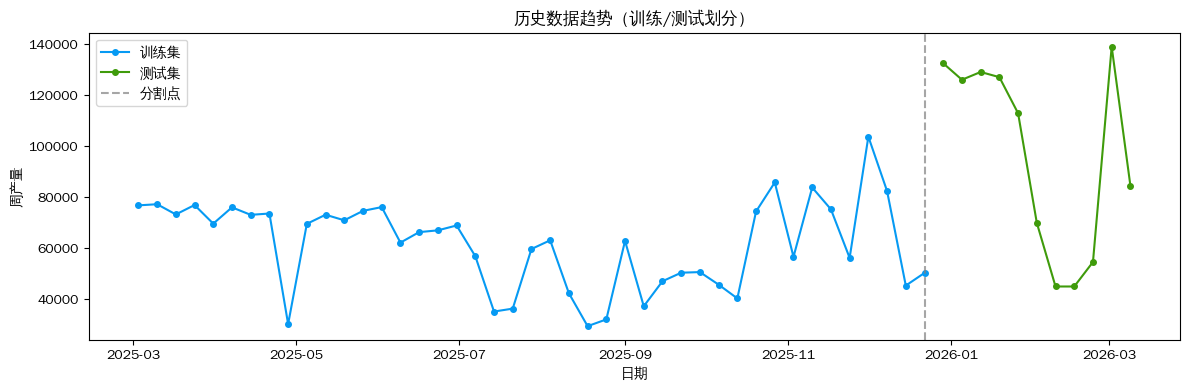

In [2]:
# 按 80/20 划分训练集和测试集
TRAIN_RATIO = 0.8
split_idx = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()
PRED_LEN = len(test_df)

print(f'训练集: {len(train_df)} 行  ({train_df["ds"].min().date()} ~ {train_df["ds"].max().date()})')
print(f'测试集: {len(test_df)} 行  ({test_df["ds"].min().date()} ~ {test_df["ds"].max().date()})')
print(f'预测步长: {PRED_LEN} 周')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_df['ds'], train_df['y'], marker='o', markersize=4, color='xkcd:azure', label='训练集')
ax.plot(test_df['ds'],  test_df['y'],  marker='o', markersize=4, color='xkcd:grass green', label='测试集')
ax.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.7, label='分割点')
ax.set_title('历史数据趋势（训练/测试划分）')
ax.set_xlabel('日期')
ax.set_ylabel('周产量')
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
# NeuralProphet 周度数据配置
m = NeuralProphet(
    n_forecasts=PRED_LEN,
    n_lags=0,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    quantiles=[0.1, 0.9],
    trainer_config={'accelerator': 'cpu'},
)
metrics = m.fit(train_df, freq='W')
print('模型训练完成')

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 203/203 [00:01<00:00, 114.37it/s]


Training: |          | 0/? [00:19<?, ?it/s, v_num=0, train_loss=0.0841, reg_loss=0.000, MAE=8.71e+3, RMSE=1.11e+4, Loss=0.0808, RegLoss=0.000]
模型训练完成


In [4]:
# 生成未来预测
future = m.make_future_dataframe(train_df, periods=PRED_LEN)
forecast = m.predict(future)

# 提取测试期预测结果
forecast_test = forecast.tail(PRED_LEN)[['ds', 'yhat1', 'yhat1 10.0%', 'yhat1 90.0%']].reset_index(drop=True)
forecast_test.columns = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
print(f'预测期: {forecast_test["ds"].iloc[0].date()} ~ {forecast_test["ds"].iloc[-1].date()}')
forecast_test

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 177.86it/s]
预测期: 2025-12-28 ~ 2026-03-08


,ds,yhat,yhat_lower,yhat_upper
0,2025-12-28,88330.453125,88330.453125,88330.453125
1,2026-01-04,91267.867188,91267.867188,91267.867188
2,2026-01-11,100492.046875,100492.046875,100492.046875
3,2026-01-18,113543.062500,113543.062500,113543.062500
4,2026-01-25,126871.445312,126871.445312,126871.445312
5,2026-02-01,136743.500000,136743.500000,136743.500000
6,2026-02-08,140973.843750,140973.843750,140973.843750
7,2026-02-15,139462.984375,139462.984375,139462.984375
8,2026-02-22,133761.906250,133761.906250,133761.906250
9,2026-03-01,126691.187500,126691.187500,126691.187500


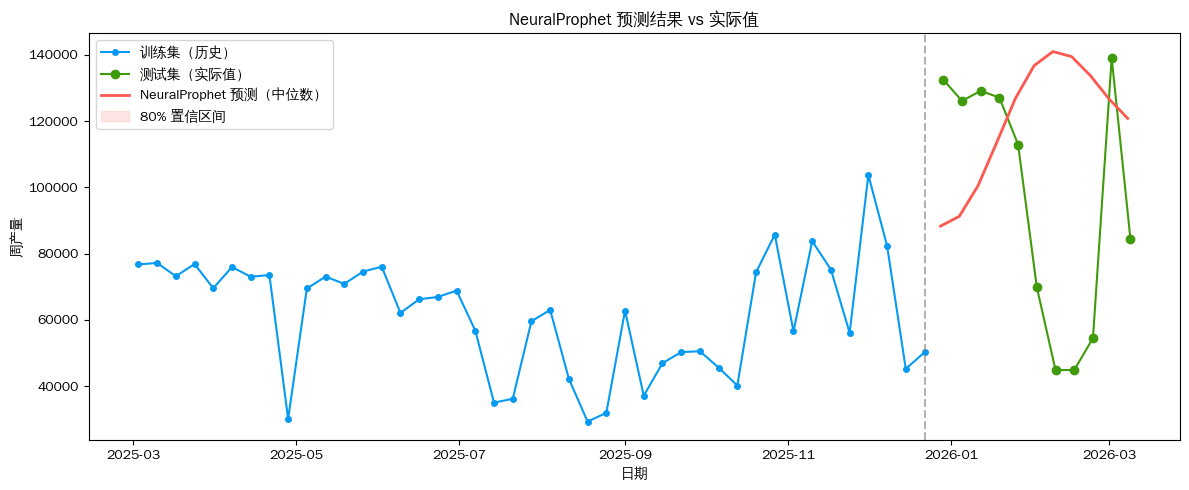

In [5]:
# 绘制预测结果 vs 实际值
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_df['ds'], train_df['y'],
        color='xkcd:azure', marker='o', markersize=4, label='训练集（历史）')
ax.plot(test_df['ds'],  test_df['y'],
        color='xkcd:grass green', marker='o', markersize=6, label='测试集（实际值）')
ax.plot(forecast_test['ds'], forecast_test['yhat'],
        color='xkcd:coral', linewidth=2, label='NeuralProphet 预测（中位数）')
ax.fill_between(forecast_test['ds'],
                forecast_test['yhat_lower'], forecast_test['yhat_upper'],
                color='xkcd:coral', alpha=0.15, label='80% 置信区间')
ax.axvline(x=train_df['ds'].iloc[-1], color='gray', linestyle='--', alpha=0.6)
ax.set_title('NeuralProphet 预测结果 vs 实际值')
ax.set_xlabel('日期')
ax.set_ylabel('周产量')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# 误差指标：MAE、RMSE、MAPE
y_true = test_df['y'].values
y_pred = forecast_test['yhat'].values

mae  = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print('─' * 35)
print(f'  MAE  (平均绝对误差):      {mae:.1f}')
print(f'  RMSE (均方根误差):        {rmse:.1f}')
print(f'  MAPE (平均绝对百分误差):  {mape:.2f}%')
print('─' * 35)

───────────────────────────────────
  MAE  (平均绝对误差):      47321.3
  RMSE (均方根误差):        56206.9
  MAPE (平均绝对百分误差):  74.86%
───────────────────────────────────
